# Fase 4 — Modelado
## TPI Ciencia de Datos — DS Airlines

Este notebook implementa la fase de modelado del Objetivo 1: clasificación de vuelos según probabilidad de demora.

**Algoritmos:** Árbol de Decisión y K-Vecinos Más Cercanos (KNN).  
**Herramienta:** Python (scikit-learn) sobre Google Colab.  
**Datos:** `vuelos.xlsx` (15.000 registros).  
**Partición:** 70/30 estratificada por la variable objetivo `demora`, semilla 42.

---

## 1. Carga de datos y librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Configuración estética
sns.set_style('whitegrid')
RANDOM_STATE = 42

In [ ]:
# Si se ejecuta en Colab, montar Google Drive o subir el archivo manualmente.
# from google.colab import files
# files.upload()

df = pd.read_excel('Vuelos.xlsx')
print(f'Dataset original: {df.shape}')
df.head()

Dataset original: (15000, 15)


,id_vuelo,aeropuerto_origen,aeropuerto_destino,hora_salida_programada,dia_semana,distancia_vuelo,condiciones_climaticas,congestion_aerea,tipo_avion,ocupacion_vuelo,temporada_alta,puerta_embarque,visibilidad,tiempo_estimado_vuelo,demora
0,10002,GIG,GRU,09:30,Miércoles,360,Despejado,Baja,Boeing 737,52.8,False,45,12.2,57,1
1,10003,TUC,EZE,11:00,Sábado,1230,Despejado,Alta,Embraer E195,54.4,True,11,10.7,132,1
2,10005,MEX,PTY,08:15,Viernes,2280,Niebla,Media,Boeing 757,48.7,True,7,1.0,199,0
3,10006,POA,GRU,06:45,Martes,1110,Despejado,Baja,Airbus A320neo,68.0,False,15,15.8,109,1
4,10008,PTY,EZE,11:30,Domingo,5100,Despejado,Baja,Airbus A330,92.0,True,36,23.0,421,0


In [ ]:
# Verificación de la distribución de la variable objetivo
print('Distribución de la variable objetivo (demora):')
print(df['demora'].value_counts(normalize=True).round(4) * 100)

Distribución de la variable objetivo (demora):
demora
0    68.15
1    31.85
Name: proportion, dtype: float64


## 2. Preparación de la vista minable

Se aplican todas las transformaciones definidas en la fase.

In [ ]:
# Conservar id_vuelo aparte para trazabilidad sobre casosNuevos
id_vuelo = df['id_vuelo'].copy()

# Variables excluidas según decisiones de la Fase 3
cols_excluidas = ['id_vuelo', 'aeropuerto_origen', 'aeropuerto_destino',
                  'tipo_avion', 'puerta_embarque', 'tiempo_estimado_vuelo']
df = df.drop(columns=cols_excluidas)

# Conversión de hora_salida_programada a numérica decimal
def hora_a_decimal(h):
    if isinstance(h, str):
        hh, mm = h.split(':')
        return int(hh) + int(mm) / 60
    return h

df['hora_salida_programada'] = df['hora_salida_programada'].apply(hora_a_decimal)

# Conversión de temporada_alta a 0/1
df['temporada_alta'] = df['temporada_alta'].astype(int)

# Codificación dummy con categorías de referencia explícitas
df = pd.get_dummies(df, columns=['dia_semana', 'condiciones_climaticas', 'congestion_aerea'],
                    drop_first=False, dtype=int)

# Eliminar las columnas de referencia (Lunes, Despejado, Baja)
referencias = ['dia_semana_Lunes', 'condiciones_climaticas_Despejado', 'congestion_aerea_Baja']
df = df.drop(columns=referencias)

print(f'Vista minable: {df.shape}')
print(f'Columnas: {list(df.columns)}')

Vista minable: (15000, 18)
Columnas: ['hora_salida_programada', 'distancia_vuelo', 'ocupacion_vuelo', 'temporada_alta', 'visibilidad', 'demora', 'dia_semana_Domingo', 'dia_semana_Jueves', 'dia_semana_Martes', 'dia_semana_Miércoles', 'dia_semana_Sábado', 'dia_semana_Viernes', 'condiciones_climaticas_Lluvia', 'condiciones_climaticas_Niebla', 'condiciones_climaticas_Nublado', 'condiciones_climaticas_Tormenta', 'congestion_aerea_Alta', 'congestion_aerea_Media']


## 3. Partición 70/30 estratificada

In [ ]:
X = df.drop(columns=['demora'])
y = df['demora']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}')
print(f'Test:  {X_test.shape}')
print(f'\nProporción demora en train: {y_train.value_counts(normalize=True).round(4).to_dict()}')
print(f'Proporción demora en test:  {y_test.value_counts(normalize=True).round(4).to_dict()}')

Train: (10500, 17)
Test:  (4500, 17)

Proporción demora en train: {0: 0.6814, 1: 0.3186}
Proporción demora en test:  {0: 0.6816, 1: 0.3184}


## 4. Escalamiento min-max

Se ajusta el escalador **solamente con el conjunto de entrenamiento** y se aplica también al conjunto de prueba.  
Las variables dummy y binarias ya están en [0, 1], por lo que no requieren escalamiento.

In [ ]:
cols_numericas = ['hora_salida_programada', 'distancia_vuelo', 'ocupacion_vuelo', 'visibilidad']

scaler = MinMaxScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test_scaled[cols_numericas] = scaler.transform(X_test[cols_numericas])

print('Verificación rango [0, 1] en train:')
X_train_scaled[cols_numericas].agg(['min', 'max']).round(4)

Verificación rango [0, 1] en train:


,hora_salida_programada,distancia_vuelo,ocupacion_vuelo,visibilidad
min,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0


## 5. Árbol de Decisión

### 5.1 Modelo base

In [ ]:
arbol_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
arbol_base.fit(X_train_scaled, y_train)

pred_train = arbol_base.predict(X_train_scaled)
pred_test = arbol_base.predict(X_test_scaled)

print('ÁRBOL DE DECISIÓN — Modelo base (parámetros por defecto)')
print(f'  Accuracy train: {accuracy_score(y_train, pred_train):.4f}')
print(f'  Accuracy test:  {accuracy_score(y_test, pred_test):.4f}')
print(f'  Profundidad real: {arbol_base.get_depth()}')
print(f'  Número de hojas: {arbol_base.get_n_leaves()}')
print('\nMatriz de confusión (test):')
print(confusion_matrix(y_test, pred_test))

ÁRBOL DE DECISIÓN — Modelo base (parámetros por defecto)
  Accuracy train: 1.0000
  Accuracy test:  0.6164
  Profundidad real: 37
  Número de hojas: 2637

Matriz de confusión (test):
[[2195  872]
 [ 854  579]]


**Observación.** El modelo base alcanza 100 % de accuracy en entrenamiento y sólo ~62 % en prueba, con una profundidad de 37 niveles. Es un caso claro de sobreajuste, lo que motiva la exploración de hiperparámetros que limiten el crecimiento del árbol.

### 5.2 Exploración de `max_depth`

In [ ]:
profundidades = [3, 5, 7, 10, 15, 20, None]
resultados = []

for d in profundidades:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    m.fit(X_train_scaled, y_train)
    err_train = 1 - accuracy_score(y_train, m.predict(X_train_scaled))
    err_test = 1 - accuracy_score(y_test, m.predict(X_test_scaled))
    cm = confusion_matrix(y_test, m.predict(X_test_scaled))
    resultados.append({
        'max_depth': str(d), 'err_train': err_train, 'err_test': err_test,
        'FN': cm[1, 0], 'FP': cm[0, 1], 'hojas': m.get_n_leaves()
    })

df_res = pd.DataFrame(resultados)
df_res

,max_depth,err_train,err_test,FN,FP,hojas
0,3,0.296190,0.293556,1174,147,8
1,5,0.289810,0.291333,1082,229,32
2,7,0.272571,0.307111,1031,351,112
3,10,0.226667,0.312444,1028,378,427
4,15,0.119143,0.347333,931,632,1386
5,20,0.041524,0.375556,895,795,2178
6,None,0.000000,0.383556,854,872,2637


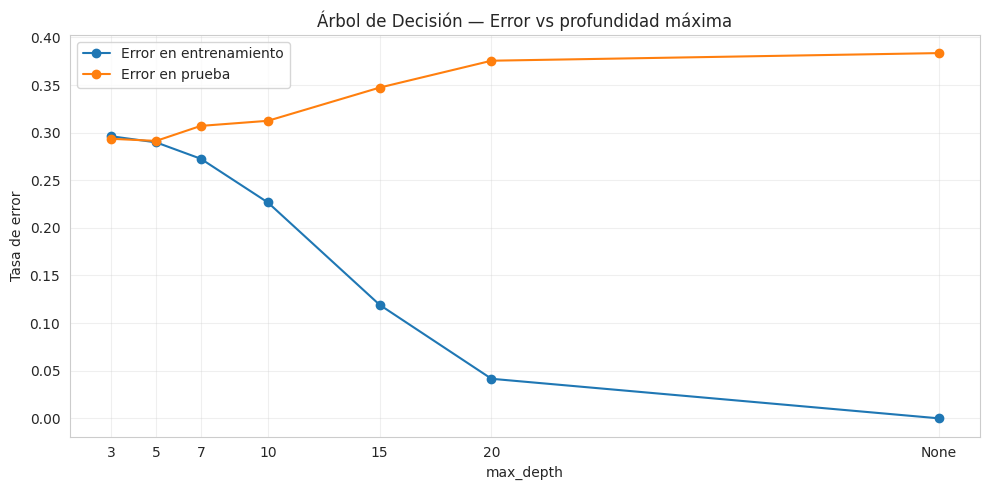

In [ ]:
# Gráfico: error vs max_depth
depths_num = [d if d is not None else 40 for d in profundidades]

plt.figure(figsize=(10, 5))
plt.plot(depths_num, df_res['err_train'], 'o-', label='Error en entrenamiento')
plt.plot(depths_num, df_res['err_test'], 'o-', label='Error en prueba')
plt.xlabel('max_depth')
plt.ylabel('Tasa de error')
plt.title('Árbol de Decisión — Error vs profundidad máxima')
plt.xticks(depths_num, [str(d) for d in profundidades])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observación.** El error de prueba alcanza su mínimo en `max_depth = 5` (≈ 29,1 %). A partir de ese valor, el error de entrenamiento sigue bajando (síntoma de sobreajuste) mientras el de prueba se deteriora. Se fija `max_depth = 5` como mejor profundidad.

### 5.3 Comparación de criterios de impureza

In [ ]:
for crit in ['gini', 'entropy']:
    m = DecisionTreeClassifier(criterion=crit, max_depth=5, random_state=RANDOM_STATE)
    m.fit(X_train_scaled, y_train)
    err_test = 1 - accuracy_score(y_test, m.predict(X_test_scaled))
    cm = confusion_matrix(y_test, m.predict(X_test_scaled))
    print(f'{crit:8s}: err_test = {err_test:.4f}  |  FN = {cm[1,0]}  FP = {cm[0,1]}')

gini    : err_test = 0.2913  |  FN = 1082  FP = 229
entropy : err_test = 0.2924  |  FN = 1097  FP = 219


**Observación.** Las diferencias entre Gini y Entropía son mínimas (apenas 0,001 puntos). Se elige Gini por ser el criterio por defecto, marginalmente mejor en este caso y computacionalmente más eficiente.

### 5.4 Modelo final — Árbol de Decisión

ÁRBOL FINAL — max_depth=5, criterion=gini
  Accuracy train: 0.7102
  Accuracy test:  0.7087
  Profundidad: 5 | Hojas: 32


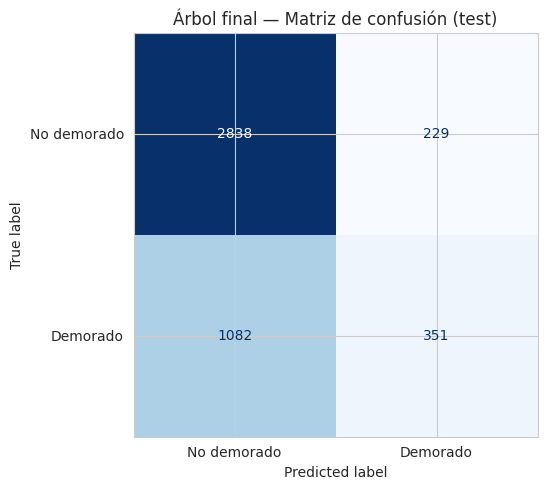


FN (falsos negativos) = 1082
FP (falsos positivos) = 229


In [ ]:
arbol_final = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=RANDOM_STATE
)
arbol_final.fit(X_train_scaled, y_train)

pred_final = arbol_final.predict(X_test_scaled)

print('ÁRBOL FINAL — max_depth=5, criterion=gini')
print(f'  Accuracy train: {accuracy_score(y_train, arbol_final.predict(X_train_scaled)):.4f}')
print(f'  Accuracy test:  {accuracy_score(y_test, pred_final):.4f}')
print(f'  Profundidad: {arbol_final.get_depth()} | Hojas: {arbol_final.get_n_leaves()}')

# Matriz de confusión visual
cm = confusion_matrix(y_test, pred_final)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['No demorado', 'Demorado']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Árbol final — Matriz de confusión (test)')
plt.tight_layout()
plt.show()

print(f'\nFN (falsos negativos) = {cm[1,0]}')
print(f'FP (falsos positivos) = {cm[0,1]}')

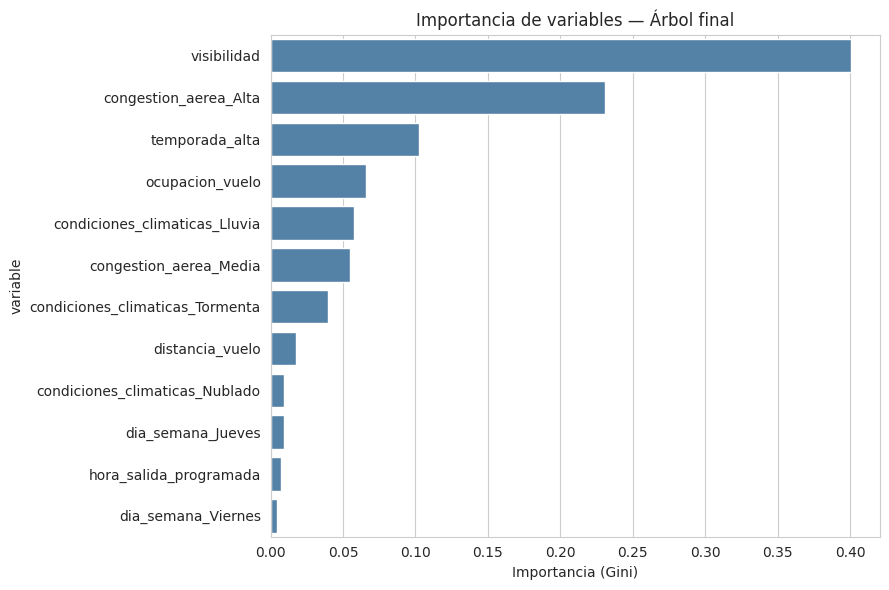

,variable,importancia
4,visibilidad,0.400622
15,congestion_aerea_Alta,0.230843
3,temporada_alta,0.102294
2,ocupacion_vuelo,0.066099
11,condiciones_climaticas_Lluvia,0.057511
16,congestion_aerea_Media,0.055045
14,condiciones_climaticas_Tormenta,0.039621
1,distancia_vuelo,0.017480
13,condiciones_climaticas_Nublado,0.009534
6,dia_semana_Jueves,0.009280


In [ ]:
# Importancia de variables
importancias = pd.DataFrame({
    'variable': X_train_scaled.columns,
    'importancia': arbol_final.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importancias[importancias['importancia'] > 0], x='importancia', y='variable', color='steelblue')
plt.title('Importancia de variables — Árbol final')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

importancias.head(10)

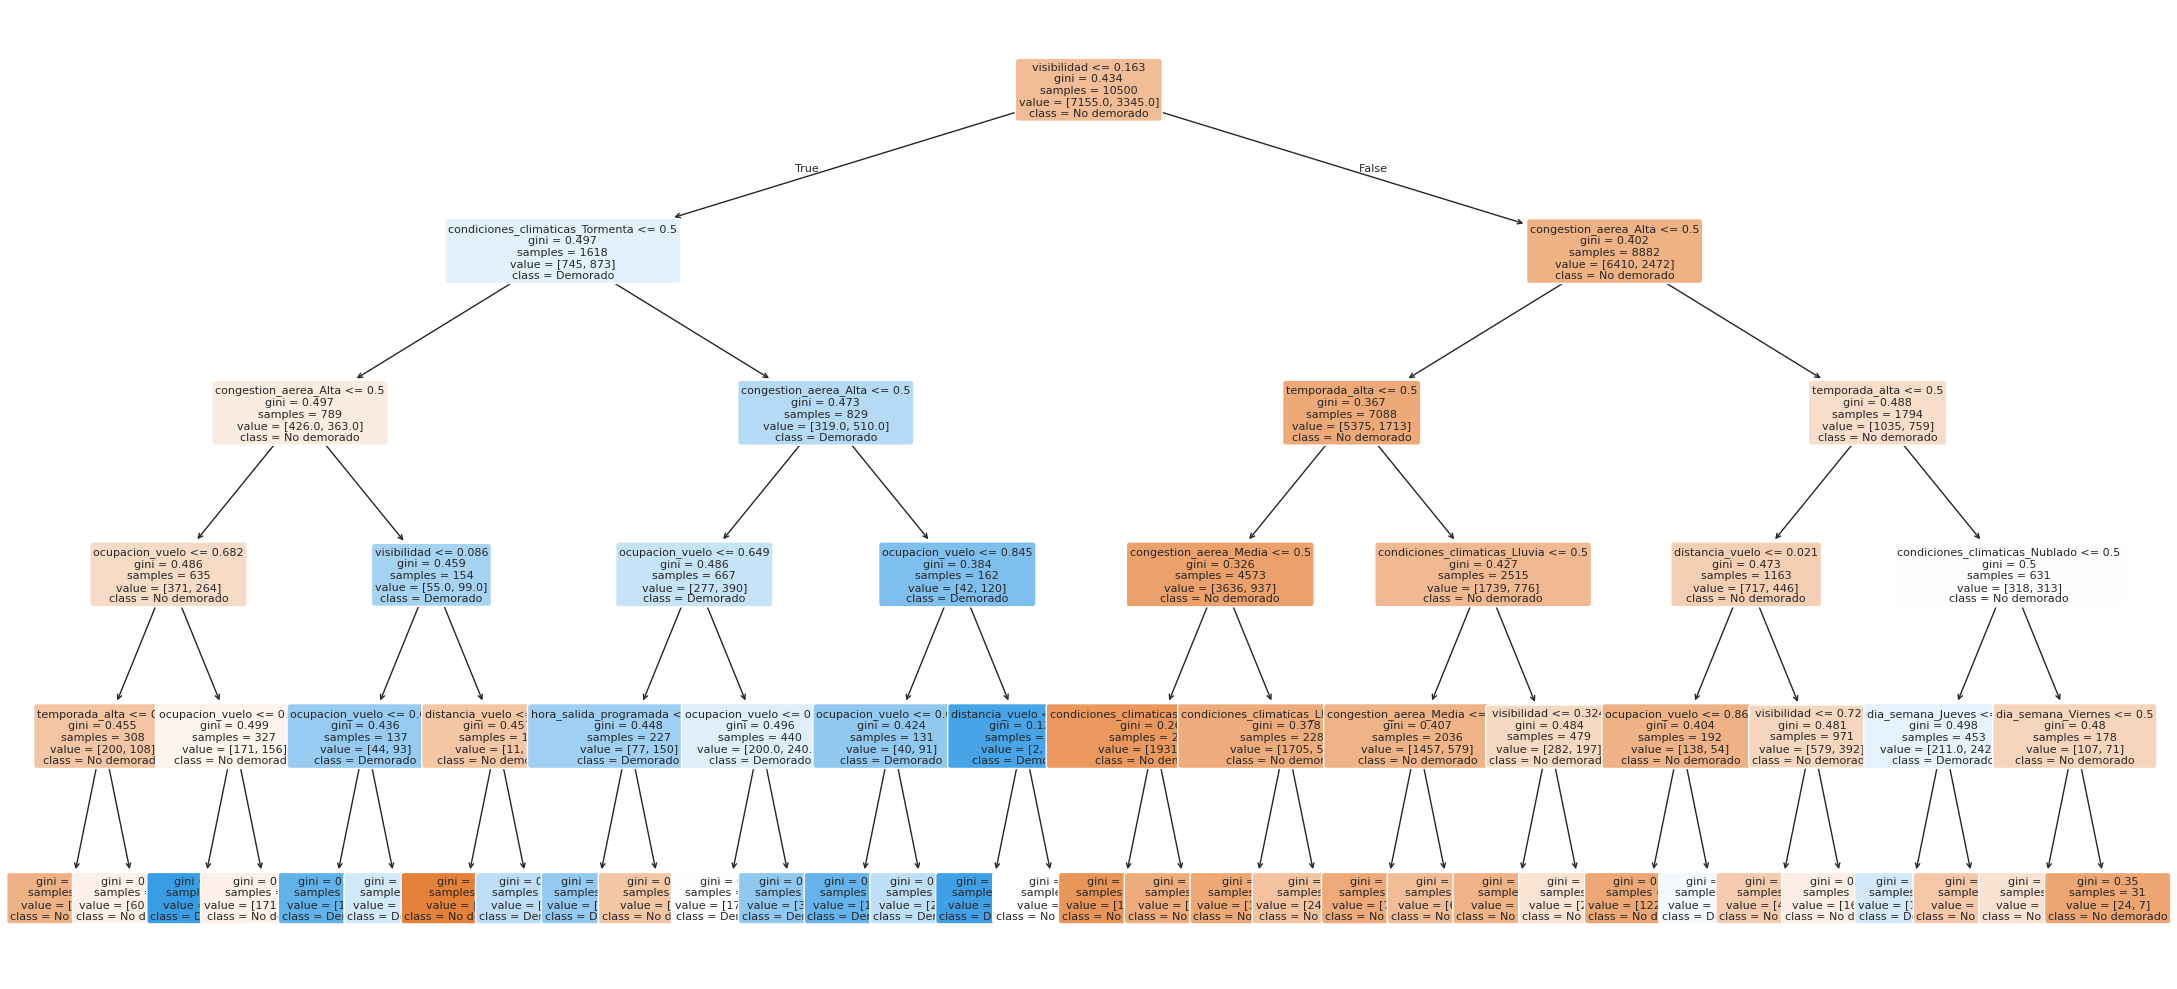

In [ ]:
# Visualización del árbol
plt.figure(figsize=(22, 10))
plot_tree(arbol_final, feature_names=X_train_scaled.columns,
          class_names=['No demorado', 'Demorado'], filled=True, fontsize=8, rounded=True)
plt.tight_layout()
plt.show()

## 6. K-Vecinos Más Cercanos (KNN)

### 6.1 Modelo base

In [ ]:
knn_base = KNeighborsClassifier()  # k=5 por defecto, métrica euclidiana
knn_base.fit(X_train_scaled, y_train)

print('KNN — Modelo base (k=5, distancia euclídea)')
print(f'  Accuracy train: {accuracy_score(y_train, knn_base.predict(X_train_scaled)):.4f}')
print(f'  Accuracy test:  {accuracy_score(y_test, knn_base.predict(X_test_scaled)):.4f}')

KNN — Modelo base (k=5, distancia euclídea)
  Accuracy train: 0.7603
  Accuracy test:  0.6707


### 6.2 Exploración del parámetro k

Se evalúa k entre 1 y 51 (valores impares) para identificar visualmente el valor óptimo.

In [ ]:
ks = list(range(1, 52, 2))
err_train_list, err_test_list, fn_list, fp_list = [], [], [], []

for k in ks:
    m = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    m.fit(X_train_scaled, y_train)
    err_train_list.append(1 - accuracy_score(y_train, m.predict(X_train_scaled)))
    err_test_list.append(1 - accuracy_score(y_test, m.predict(X_test_scaled)))
    cm = confusion_matrix(y_test, m.predict(X_test_scaled))
    fn_list.append(cm[1, 0])
    fp_list.append(cm[0, 1])

df_knn = pd.DataFrame({
    'k': ks, 'err_train': err_train_list, 'err_test': err_test_list,
    'FN': fn_list, 'FP': fp_list
})
df_knn

,k,err_train,err_test,FN,FP
0,1,0.000000,0.385333,884,850
1,3,0.196095,0.350889,953,626
2,5,0.239714,0.329333,997,485
3,7,0.257619,0.319778,1015,424
4,9,0.268381,0.318222,1025,407
5,11,0.274667,0.316000,1047,375
6,13,0.277333,0.310444,1059,338
7,15,0.279238,0.312222,1069,336
8,17,0.278476,0.307111,1064,318
9,19,0.280476,0.303333,1069,296


Mejor k: 41 con error de test = 0.2960


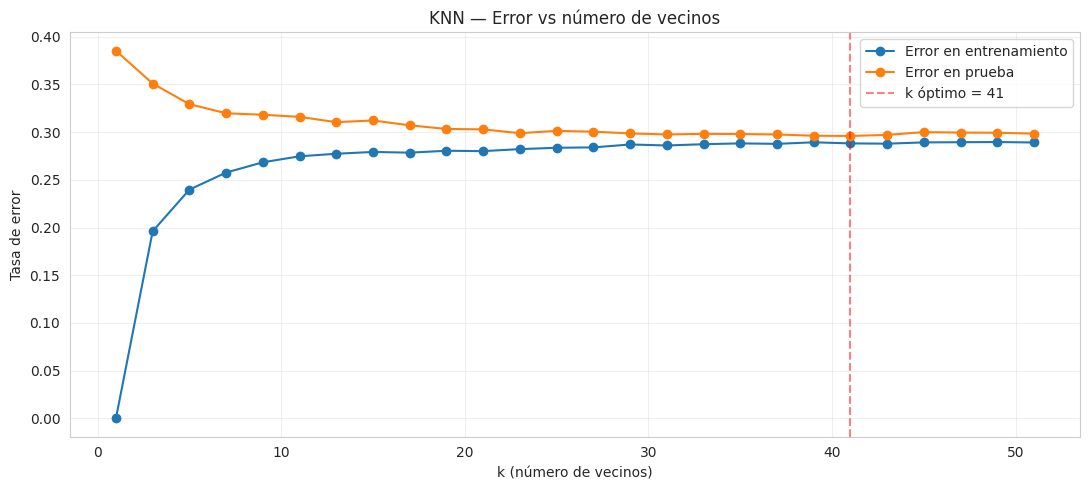

In [ ]:
# Identificar el mejor k
k_optimo = int(df_knn.loc[df_knn['err_test'].idxmin(), 'k'])
err_optimo = df_knn['err_test'].min()
print(f'Mejor k: {k_optimo} con error de test = {err_optimo:.4f}')

# Gráfico
plt.figure(figsize=(11, 5))
plt.plot(ks, err_train_list, 'o-', label='Error en entrenamiento')
plt.plot(ks, err_test_list, 'o-', label='Error en prueba')
plt.axvline(x=k_optimo, color='red', linestyle='--', alpha=0.5, label=f'k óptimo = {k_optimo}')
plt.xlabel('k (número de vecinos)')
plt.ylabel('Tasa de error')
plt.title('KNN — Error vs número de vecinos')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observación.** Con k = 1, el modelo memoriza el conjunto de entrenamiento (error de train = 0) pero generaliza mal sobre el conjunto de prueba (error ≈ 38,5 %). A medida que k crece, el error de entrenamiento aumenta (menor sobreajuste) y el de prueba se reduce y se estabiliza. El mínimo se alcanza en k = 41.

### 6.3 Modelo final — KNN

KNN FINAL — k=41, distancia euclídea
  Accuracy train: 0.7118
  Accuracy test:  0.7040


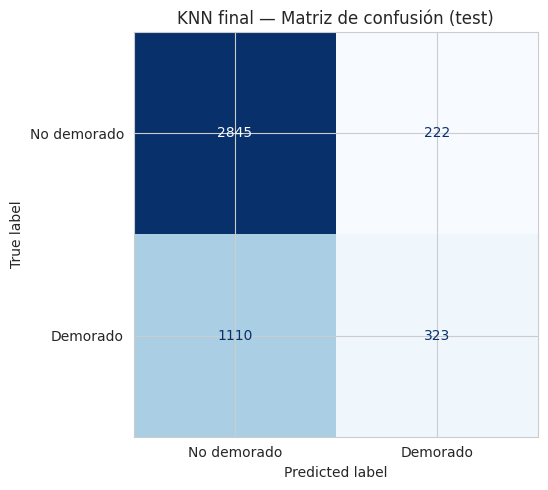


FN = 1110  |  FP = 222


In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=41, metric='euclidean')
knn_final.fit(X_train_scaled, y_train)

pred_knn_final = knn_final.predict(X_test_scaled)

print('KNN FINAL — k=41, distancia euclídea')
print(f'  Accuracy train: {accuracy_score(y_train, knn_final.predict(X_train_scaled)):.4f}')
print(f'  Accuracy test:  {accuracy_score(y_test, pred_knn_final):.4f}')

cm = confusion_matrix(y_test, pred_knn_final)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['No demorado', 'Demorado']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('KNN final — Matriz de confusión (test)')
plt.tight_layout()
plt.show()

print(f'\nFN = {cm[1,0]}  |  FP = {cm[0,1]}')

## 7. Resumen comparativo de los modelos finalistas

In [ ]:
cm_a = confusion_matrix(y_test, arbol_final.predict(X_test_scaled))
cm_k = confusion_matrix(y_test, knn_final.predict(X_test_scaled))

resumen = pd.DataFrame({
    'Modelo': ['Árbol (max_depth=5, gini)', 'KNN (k=41, euclídea)'],
    'Accuracy test': [accuracy_score(y_test, arbol_final.predict(X_test_scaled)),
                      accuracy_score(y_test, knn_final.predict(X_test_scaled))],
    'VN': [cm_a[0,0], cm_k[0,0]],
    'FP': [cm_a[0,1], cm_k[0,1]],
    'FN': [cm_a[1,0], cm_k[1,0]],
    'VP': [cm_a[1,1], cm_k[1,1]],
})
resumen

,Modelo,Accuracy test,VN,FP,FN,VP
0,"Árbol (max_depth=5, gini)",0.708667,2838,229,1082,351
1,"KNN (k=41, euclídea)",0.704000,2845,222,1110,323


---

Ambos modelos (Árbol con `max_depth=5` y KNN con `k=41`) quedan listos para ser comparados mediante la matriz de costos y el gráfico de ganancia.